In [1]:
import sys; sys.path.append('..')
from osp import *
pd.options.display.max_colwidth = 200
pd.options.display.max_rows = 20

In [2]:
groups_train = [
    ('Group 1', 'discipline in ["Philosophy"]'),
    ('Group 2', 'discipline in ["Literature"]'),
]

In [4]:
get_balanced_slice_sample(groups_train, sample_size=10)

,discipline,title,author,journal,year,period,text_id,slice_id,_target
0,Philosophy,Heidegger's (Dramatic?) Dialogues,Drew A. Hyland,Research in Phenomenology,2015,2000-2025,phil/10.2307/24659921,phil/10.2307/24659921__03,Group 1
1,Philosophy,Two Views on Kant and Formal Logic,Harold R. Smart,Philosophy and Phenomenological Research,1955,1950-1975,phil/10.2307/2103770,phil/10.2307/2103770__03,Group 1
2,Philosophy,Outline of a Theory of Scientific Understanding,"Karel Lambert, Gerhard Schurz",Synthese,1994,1975-2000,phil/10.2307/20117948,phil/10.2307/20117948__01,Group 1
3,Philosophy,Giving Due: Heidegger's Interpretation of the Anaximander Fragment,KARIN De BOER,Research in Phenomenology,1997,1975-2000,phil/10.2307/24654674,phil/10.2307/24654674__04,Group 1
4,Philosophy,Structural Essentialism and Determinism,Jerzy Gołosz,Erkenntnis,2005,2000-2025,phil/10.2307/20013348,phil/10.2307/20013348__03,Group 1
5,Philosophy,De-Moralizing Freud,Joseph Ratner,The Journal of Philosophy,1924,1900-1925,phil/10.2307/2014347,phil/10.2307/2014347__01,Group 1
6,Philosophy,Out of the Closet: Frege's Boots,Thomas H. Smith,Proceedings of the Aristotelian Society,2006,2000-2025,phil/10.2307/4545469,phil/10.2307/4545469__01,Group 1
7,Philosophy,"Iterated Belief Revision, Reliability, and Inductive Amnesia",Kevin T. Kelly,Erkenntnis,1999,1975-2000,phil/10.2307/20012901,phil/10.2307/20012901__04,Group 1
8,Philosophy,Invisible Disability,N. Ann Davis,Ethics,2005,2000-2025,phil/10.1086/453151,phil/10.1086/453151__19,Group 1
9,Philosophy,"Individualism, Externalism and Idiolectical Meaning",Robert Eamon Briscoe,Synthese,2006,2000-2025,phil/10.2307/20118838,phil/10.2307/20118838__04,Group 1


In [6]:
odf=get_balanced_cv_data(groups_train, feat_types=None)

Signature: get_text_slice_ids(id, n_slices=10)
Docstring: <no docstring>
Source:   
def get_text_slice_ids(id, n_slices=10):
    from .constants import STASH_SLICES_NLP
    
    return [
        f'{id}__{slice_id:02d}'
        for slice_id in range(1,n_slices+1)
        if f'{id}__{slice_id:02d}' in STASH_SLICES_NLP
    ]
File:      ~/github/ordinary-style-philosophy/osp/slices.py
Type:      function

In [12]:
@cache
def get_text_id2slice_ids():
    out = defaultdict(list)
    for k in get_parsed_slice_ids():
        out[k.split('__')[0]].append(k)
    return out

text2slice_ids = get_text_id2slice_ids()
# text2slice_ids

In [ ]:
def get_balanced_slice_sample(groups_train, sample_size=None, verbose=True):
    name1, query1 = groups_train[0]
    name2, query2 = groups_train[1]

    df_meta = get_corpus_metadata()
    df_meta_g1 = df_meta.query(query1)
    df_meta_g2 = df_meta.query(query2)

    slice_ids_g1 = [slice_id for text_id in df_meta_g1.index for slice_id in text2slice_ids[text_id]]
    slice_ids_g2 = [slice_id for text_id in df_meta_g2.index for slice_id in text2slice_ids[text_id]]

    min_size = min(len(slice_ids_g1), len(slice_ids_g2))
    if sample_size is None or sample_size > min_size:
        sample_size = min_size

    slice_ids_g1 = random.sample(slice_ids_g1, sample_size)
    slice_ids_g2 = random.sample(slice_ids_g2, sample_size)

    df_slice_ids_g1 = pd.DataFrame(slice_ids_g1, columns=['slice_id']).assign(_target=name1)
    df_slice_ids_g2 = pd.DataFrame(slice_ids_g2, columns=['slice_id']).assign(_target=name2)
    
    df_slice_ids = pd.concat([df_slice_ids_g1, df_slice_ids_g2])
    df_slice_ids['text_id'] = df_slice_ids.slice_id.str.split('__').str[0]
    df_slice_ids = df_slice_ids[['text_id', 'slice_id','_target']]
    odf = df_meta[DF_PREDS_METADATA_COLS].merge(df_slice_ids, left_on='id', right_on='text_id', how='right')
    
    return odf
    
    
    

In [57]:
get_balanced_slice_samples(groups_train)

,discipline,title,author,journal,year,period,text_id,slice_id,_target
0,Philosophy,The points of concepts,Matthieu Queloz,Canadian Journal of Philosophy,2019,2000-2025,phil/10.2307/48547400,phil/10.2307/48547400__01,Group 1
1,Philosophy,Alternative possibilities and asymmetry,Erasmus Mayr,Synthese,2019,2000-2025,phil/10.2307/48704121,phil/10.2307/48704121__05,Group 1
2,Philosophy,Wittgenstein and Neuroscience,James C. Klagge,Synthese,1989,1975-2000,phil/10.2307/20116624,phil/10.2307/20116624__03,Group 1
3,Philosophy,Why neither diachronic universalism nor the Argument from Vagueness establishes perdurantism,Ofra Magidor,Canadian Journal of Philosophy,2015,2000-2025,phil/10.2307/26444366,phil/10.2307/26444366__03,Group 1
4,Philosophy,The Fallow Years of Franklin D. Roosevelt,R. G. Tugwell,Ethics,1956,1950-1975,phil/10.2307/2378648,phil/10.2307/2378648__07,Group 1
...,...,...,...,...,...,...,...,...,...
22407,Literature,The First Collection of Dutch Love Emblems: The Identity of Theocritus à Ganda,Paul R. Sellin,The Modern Language Review,1971,1950-1975,lit/3722891,lit/3722891__02,Group 2
22408,Literature,Was Goethe Wrong about the Nineteenth-Century Lied? An Examination of the Relation of Poem and Music,Jack M. Stein,PMLA,1962,1950-1975,lit/460482,lit/460482__02,Group 2
22409,Literature,Models of Globalization,Reingard Nethersole,PMLA,2001,2000-2025,lit/463504,lit/463504__01,Group 2
22410,Literature,"Melancholy, Ambition, and Revenge in Belleforest's Hamlet",A. P. Stabler,PMLA,1966,1950-1975,lit/460806,lit/460806__01,Group 2


In [58]:
get_balanced_slice_samples(groups_train)

,discipline,title,author,journal,year,period,text_id,slice_id,_target
0,Philosophy,Engagement for progress: applied philosophy of science in context,Heather Douglas,Synthese,2010,2000-2025,phil/10.2307/40985707,phil/10.2307/40985707__01,Group 1
1,Philosophy,"A social epistemology of aesthetics: belief polarization, echo chambers and aesthetic judgement",Jon Robson,Synthese,2014,2000-2025,phil/10.2307/24019975,phil/10.2307/24019975__04,Group 1
2,Philosophy,Functionalism and Personal Identity,Lawrence H. Davis,Philosophy and Phenomenological Research,1998,1975-2000,phil/10.2307/2653722,phil/10.2307/2653722__03,Group 1
3,Philosophy,Quantifying over the Reals,"Philip Hugly, Charles Sayward",Synthese,1994,1975-2000,phil/10.2307/20117947,phil/10.2307/20117947__02,Group 1
4,Philosophy,The Social Philosophy of Karl Marx,Abram L. Harris,Ethics,1948,1925-1950,phil/10.2307/2379097,phil/10.2307/2379097__18,Group 1
...,...,...,...,...,...,...,...,...,...
22407,Literature,"The ""Rights of Woman"" in the Age of Reason",A. R. Humphreys,The Modern Language Review,1946,1925-1950,lit/3717059,lit/3717059__01,Group 2
22408,Literature,The Last Scene in Goethe's Faust,G. C. L. Schuchard,PMLA,1949,1925-1950,lit/459744,lit/459744__05,Group 2
22409,Literature,"""Plainly Partial"": The Liberal Areopagitica",William Kolbrener,ELH,1993,1975-2000,lit/2873307,lit/2873307__02,Group 2
22410,Literature,The Vocative and the Vocational: The Unreadability of Elizabeth in the Faerie Queene,Elizabeth J. Bellamy,ELH,1987,1975-2000,lit/2873047,lit/2873047__01,Group 2


In [11]:
df_meta = get_corpus_metadata()

In [13]:
# df_meta.query(groups_train[0][1])

In [ ]:

get_balanced_cv_data(groups_train)

In [15]:
get_all_text_slice_ids()

['phil/10.2307/45238188__01',
 'phil/10.2307/45238188__02',
 'phil/10.2307/45238188__03',
 'phil/10.2307/45238188__04',
 'phil/10.2307/45238188__05',
 'phil/10.2307/45238188__06',
 'phil/10.2307/45238188__07',
 'phil/10.2307/20115538__01',
 'phil/10.2307/20115538__02',
 'phil/10.2307/40380502__01',
 'phil/10.2307/40380502__02',
 'phil/10.2307/40380502__03',
 'phil/10.2307/40380502__04',
 'phil/10.2307/24659549__01',
 'phil/10.2307/24659549__02',
 'phil/10.2307/24659549__03',
 'phil/10.2307/20620123__01',
 'phil/10.2307/20620123__02',
 'phil/10.2307/20620123__03',
 'phil/10.2307/20620123__04',
 'phil/10.2307/2378543__01',
 'phil/10.2307/2378543__02',
 'phil/10.2307/27293791__01',
 'phil/10.2307/27293791__02',
 'phil/10.2307/27293791__03',
 'phil/10.2307/27293791__04',
 'phil/10.2307/27293791__05',
 'phil/10.2307/27293791__06',
 'phil/10.2307/27293791__07',
 'phil/10.1086/233202__01',
 'phil/10.1086/233202__02',
 'phil/10.1086/233202__03',
 'phil/10.1086/233202__04',
 'phil/10.1086/23320

In [4]:
doc = get_nlp_doc(newtxt)

In [4]:
df_feat_weights = get_current_feat_weights()
df_feat_weights.sort_values('weight_z', ascending=False)

,weight,run,feat_desc,score_mean1,score_mean2,score_z1,score_z2,score_mean_diff,score_mean_diff_abs,score_mean_diff_pct,score_mean_div,score_mean_div_abs,score_z_diff,score_z_diff_abs,score_z_diff_pct,score_z_div,score_z_div_abs,weight_z
feature,,,,,,,,,,,,,,,,,,
pos_FW,0.544264,4.5,NaN,0.745575,0.307926,0.731872,0.307926,0.437649,0.509881,2.308369,3.308369,3.308369,0.423945,0.488889,2.227638,3.227638,3.227638,5.650830
pos_-RRB-,0.205474,4.5,NaN,3.550137,2.885564,3.602599,2.885564,0.664573,1.351894,0.160803,1.160803,1.160803,0.717036,1.372547,0.182869,1.182869,1.182869,2.121106
pos_EX,0.181848,4.5,NaN,2.806014,1.580340,2.801033,1.580340,1.225674,1.225674,0.874250,1.874250,1.874250,1.220692,1.220692,0.869475,1.869475,1.869475,1.874958
deprel_dep,0.157693,4.5,NaN,0.298564,0.571534,0.302779,0.571534,-0.272970,0.272970,-0.440303,0.559697,0.559697,-0.268754,0.268754,-0.433188,0.566812,0.566812,1.623298
pos_NFP,0.144514,4.5,NaN,0.258818,0.133490,0.265688,0.133490,0.125327,0.148025,1.711783,2.711783,2.711783,0.132198,0.150423,1.795791,2.795791,2.795791,1.485986
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
pos_RBS,-0.186971,4.5,NaN,0.599503,0.863941,0.601870,0.863941,-0.264438,0.264438,-0.302392,0.697608,0.697608,-0.262071,0.262071,-0.298854,0.701146,0.701146,-1.967630
pos_-LRB-,-0.200537,4.5,NaN,3.703692,3.519783,3.751760,3.519783,0.183908,1.408359,0.007314,1.007314,1.007314,0.231976,1.419019,0.022824,1.022824,1.022824,-2.108965
pos_UH,-0.212537,4.5,NaN,0.587247,0.993451,0.571328,0.993451,-0.406204,0.406204,-0.339454,0.660546,0.660546,-0.422123,0.422123,-0.353602,0.646398,0.646398,-2.233997


In [6]:
df_feat_weights.weight_z.describe().round(2)


count    97.00
mean     -0.00
std       1.00
min      -2.38
25%      -0.43
50%      -0.03
75%       0.30
max       5.65
Name: weight_z, dtype: float64

,sent_i,word_i,word,pos,deprel,context,sent_height,sent_num_words_in_dependent_clauses,sent_num_words_in_independent_clauses,sent_num_independent_clauses,sent_num_dependent_clauses
0,0,0,by,IN,case,BY a ` denoting phrase,833.333333,0.000000,1000.000000,0.000000,0.000000
1,0,1,a,DT,det,By A ` denoting phrase,833.333333,0.000000,1000.000000,0.000000,0.000000
2,0,2,`,``,punct,By a ` denoting phrase,833.333333,0.000000,1000.000000,0.000000,0.000000
3,0,3,denoting,VBG,amod,By a ` DENOTING phrase,833.333333,0.000000,1000.000000,0.000000,0.000000
4,0,4,phrase,NN,root,a ` denoting PHRASE,833.333333,0.000000,1000.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
223,5,23,am,VBP,cop,theory which I AM about to explain,535.714286,535.714286,464.285714,35.714286,107.142857
224,5,24,about,JJ,acl:relcl,theory which I am ABOUT to explain,535.714286,535.714286,464.285714,35.714286,107.142857
225,5,25,to,TO,mark,which I am about TO explain,535.714286,535.714286,464.285714,35.714286,107.142857
226,5,26,explain,VB,xcomp,am about to EXPLAIN,535.714286,535.714286,464.285714,35.714286,107.142857


In [ ]:
def get_slice_feats_by_word(doc, weight_cols = ['weight','score_mean1','score_mean2']):
    df_feat_weights = get_current_feat_weights()
    df_slice_feats = extract_slice_feats(doc, return_dict=False)

    o = []
    df_slice_feats_sent = df_slice_feats.drop_duplicates(subset=['sent_i'])
    for i,row in df_slice_feats.iterrows():
        meta_d = {
            'sent_i':row['sent_i'],
            'word_i':row['word_i'],
        }
        pos = row['pos']
        deprel = row['deprel']
        out_d1 = {**meta_d, 'feature':f'pos_{pos}', 'value':1}
        out_d2 = {**meta_d, 'feature':f'deprel_{deprel}', 'value':1}
        o.extend([out_d1,out_d2])

    for i,row in df_slice_feats_sent.iterrows():
        meta_d = {
            'sent_i':row['sent_i'],
            'word_i':row['word_i'],
        }
        for c in row.index:
            if c.startswith('sent_') and c.split('_')[-1] not in ['i','id']:
                out_d = {**meta_d, 'feature':c, 'value':row[c]}
                o.append(out_d)

    odf_slice_feats = pd.DataFrame(o)
    odf_slice_feats = odf_slice_feats.merge(df_feat_weights[weight_cols], on='feature', how='left').dropna()
    odf_slice_feats['feat_type'] = odf_slice_feats.feature.str.split('_').str[0]
    return odf_slice_feats

In [44]:
df=get_slice_feats_by_word(doc)
df

,sent_i,word_i,feature,value,weight,score_mean1,score_mean2
0,0,0,pos_IN,1.000000,-0.060646,140.420681,136.429146
1,0,0,deprel_case,1.000000,0.020539,111.446320,121.933452
2,0,1,pos_DT,1.000000,0.031121,104.189947,103.773237
3,0,1,deprel_det,1.000000,-0.072119,97.939451,99.222052
5,0,2,deprel_punct,1.000000,-0.013261,118.051868,132.843315
...,...,...,...,...,...,...,...
481,5,0,sent_height,535.714286,0.005876,496.628185,462.580322
482,5,0,sent_num_words_in_dependent_clauses,535.714286,0.006593,625.873518,469.452723
483,5,0,sent_num_words_in_independent_clauses,464.285714,0.007678,381.737668,531.235980
484,5,0,sent_num_independent_clauses,35.714286,-0.005695,58.119852,58.514766


<Axes: ylabel='Frequency'>

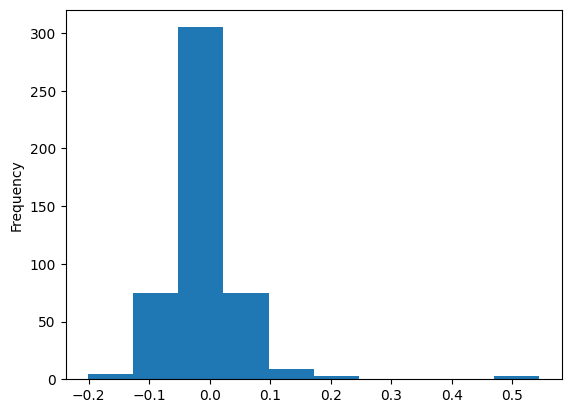

In [21]:
df_slice_feats

""


In [2]:
stopx

NameError: name 'stopx' is not defined

In [2]:
df_preds, df_feats, d_models = get_preds_feats()

In [4]:
df = get_dashboard_df_feats()
df

,W1925,W1950,W1975,W2000,vals_W,P1925,P1950,P1975,P2000,vals_P,...,P2000/P1925,vals_P/P1925,L1950/L1925,L1975/L1925,L2000/L1925,vals_L/L1925,W1950/W1925,W1975/W1925,W2000/W1925,vals_W/W1925
feature,,,,,,,,,,,,,,,,,,,,,
deprel_acl,0.093,0.000,0.025,0.026,"[0.093, 0.0, 0.025, 0.026]",10.073,10.931,11.719,12.192,"[10.073, 10.931, 11.719, 12.192]",...,0.191,"[0, 0.08174421235115423, 0.15135287931592104, 0.19092142198374637]",0.023,0.096,0.142,"[0, 0.022861454021669846, 0.09585426977395334, 0.14202032112644988]",0.000,0.269,0.280,"[0, 0.0, 0.2688172043010753, 0.27956989247311825]"
deprel_acl:relcl,-0.007,-0.078,-0.021,-0.013,"[-0.007, -0.078, -0.021, -0.013]",13.908,14.222,14.179,13.839,"[13.908, 14.222, 14.179, 13.839]",...,-0.005,"[0, 0.02232584731571125, 0.01929778260980593, -0.004973520901821724]",0.121,0.230,0.226,"[0, 0.12068662628648073, 0.23004925022406944, 0.2255733283075826]",11.143,3.000,1.857,"[0, 11.142857142857142, 3.0, 1.857142857142857]"
deprel_advcl,0.047,-0.029,-0.032,-0.043,"[0.047, -0.029, -0.032, -0.043]",17.655,19.303,19.463,20.499,"[17.655, 19.303, 19.463, 20.499]",...,0.149,"[0, 0.0892414948653884, 0.0974961978800883, 0.14935707508640106]",0.048,0.081,0.096,"[0, 0.04830590929571999, 0.08126670705950727, 0.09630370454550612]",-0.617,-0.681,-0.915,"[0, -0.6170212765957447, -0.6808510638297872, -0.9148936170212765]"
deprel_advcl:relcl,0.107,0.151,0.029,0.074,"[0.107, 0.151, 0.029, 0.074]",0.408,0.534,0.671,0.865,"[0.408, 0.534, 0.671, 0.865]",...,0.751,"[0, 0.2691286645560333, 0.49750196256752016, 0.7514623325277177]",0.084,0.258,0.424,"[0, 0.08384797247787548, 0.2580941152662848, 0.4237612371551023]",1.411,0.271,0.692,"[0, 1.411214953271028, 0.2710280373831776, 0.6915887850467289]"
deprel_advmod,-0.045,0.015,0.057,0.028,"[-0.045, 0.015, 0.057, 0.028]",53.134,54.860,55.546,56.069,"[53.134, 54.86, 55.546, 56.069]",...,0.054,"[0, 0.03196746084872277, 0.044394481631541596, 0.05376605046650861]",0.020,0.012,-0.021,"[0, 0.0202938193398139, 0.012246101072184082, -0.020650781451694356]",-0.333,-1.267,-0.622,"[0, -0.3333333333333333, -1.2666666666666668, -0.6222222222222222]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sent_height,0.003,0.012,0.011,0.005,"[0.003, 0.012, 0.011, 0.005]",487.789,496.926,511.749,523.628,"[487.789, 496.926, 511.749, 523.628]",...,0.071,"[0, 0.018558186348693554, 0.04795133515829213, 0.07089857323972944]",-0.018,-0.027,-0.030,"[0, -0.01768731492886335, -0.02728613235164385, -0.030031532899528847]",4.000,3.667,1.667,"[0, 4.0, 3.6666666666666665, 1.6666666666666667]"
sent_num_dependent_clauses,0.056,0.046,0.054,0.096,"[0.056, 0.046, 0.054, 0.096]",42.159,46.864,47.106,49.267,"[42.159, 46.864, 47.106, 49.267]",...,0.156,"[0, 0.10580160529865991, 0.110952196657456, 0.1558063009362503]",0.036,0.063,0.045,"[0, 0.03584698354665597, 0.06273016817493537, 0.04516801448818684]",0.821,0.964,1.714,"[0, 0.8214285714285714, 0.9642857142857143, 1.7142857142857142]"
sent_num_independent_clauses,0.003,0.020,0.001,0.008,"[0.003, 0.02, 0.001, 0.008]",57.755,59.126,58.841,59.311,"[57.755, 59.126, 58.841, 59.311]",...,0.027,"[0, 0.023460834247663584, 0.018628965089508048, 0.026584860530996693]",-0.001,-0.047,-0.078,"[0, -0.0014983271486403926, -0.04684485894047094, -0.07757674834520879]",6.667,0.333,2.667,"[0, 6.666666666666667, 0.3333333333333333, 2.6666666666666665]"
